In [1]:
# ==============================================================
# Libraries
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import treecorr

In [2]:
# ==============================================================
# Catalog Generators (Isotropic and Dipolar)
# ==============================================================

def generate_catalog(n_sources, A=0.0, direction=(0, 0), seed=None):
    """
    Generates a sky catalog of point sources.

    For A=0, sources are distributed isotropically over the full sphere.
    For A>0, a dipole anisotropy is injected via rejection sampling, where
    the acceptance probability follows P(n) ∝ 1 + A*(n · d), with d being
    the unit vector along the dipole direction.

    Parameters
    ----------
    n_sources : int
        Number of sources to generate.
    A : float
        Dipole amplitude. 0 = isotropic, >0 = anisotropic.
    direction : tuple (ra_deg, dec_deg)
        Sky direction of the dipole axis in degrees.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    pd.DataFrame with columns ['RA', 'DEC'] in degrees.
    """
    
    rng = np.random.default_rng(seed)

    # --- Isotropic case: direct sampling ---
    # RA is uniform in [0, 360); DEC is drawn from arcsin(uniform) to ensure
    # uniform area coverage on the sphere.
    if A == 0:
        ra  = 360.0 * rng.random(n_sources)
        dec = np.degrees(np.arcsin(2.0 * rng.random(n_sources) - 1.0))
        return pd.DataFrame({"RA": ra, "DEC": dec})

    # --- Dipole case: rejection sampling ---
    # Convert dipole direction to a Cartesian unit vector.
    ra_d, dec_d = np.deg2rad(direction)
    d = np.array([
        np.cos(dec_d) * np.cos(ra_d),
        np.cos(dec_d) * np.sin(ra_d),
        np.sin(dec_d)
    ])

    ra_out, dec_out = [], []

    while len(ra_out) < n_sources:
        # Draw a candidate point uniformly on the sphere.
        ra_try  = 360.0 * rng.random()
        dec_try = np.degrees(np.arcsin(2.0 * rng.random() - 1.0))

        # Convert candidate to a Cartesian unit vector.
        phi = np.deg2rad(ra_try)
        theta = np.deg2rad(dec_try)
        n = np.array([
            np.cos(theta) * np.cos(phi),
            np.cos(theta) * np.sin(phi),
            np.sin(theta)
        ])

        # Acceptance probability: normalized so that p <= 1 for all directions.
        # Dividing by (1 + |A|) guarantees the maximum of P(n) is exactly 1.
        p = (1.0 + A * np.dot(n, d)) / (1.0 + abs(A))

        if rng.random() < p:
            ra_out.append(ra_try)
            dec_out.append(dec_try)

    return pd.DataFrame({"RA": ra_out, "DEC": dec_out})

In [3]:
# ==============================================================
# 2pACF Calculation via TreeCorr (Landy-Szalay Estimator)
# ==============================================================

def get_2pacf(df_data, df_rand, min_sep=0.1, max_sep=180.0, nbins=20):
    """
    Computes the Angular Two-Point Correlation Function (2pACF) using the
    Landy-Szalay estimator: w(θ) = (DD - 2*DR + RR) / RR.

    TreeCorr handles all pair counting and internal normalization, accounting
    for the ratio N_data / N_rand automatically.

    Parameters
    ----------
    df_data : pd.DataFrame
        Observed catalog with columns ['RA', 'DEC'].
    df_rand : pd.DataFrame
        Random (unclustered) reference catalog with columns ['RA', 'DEC'].
    min_sep : float
        Minimum angular separation in degrees.
    max_sep : float
        Maximum angular separation in degrees.
    nbins : int
        Number of logarithmic angular bins.

    Returns
    -------
    theta : np.ndarray
        Angular bin centers in degrees (geometric mean of log bins).
    xi : np.ndarray
        Correlation function values w(θ).
    """
    
    # Build TreeCorr catalogs from RA/DEC columns.
    cat = treecorr.Catalog(
        ra=df_data["RA"], dec=df_data["DEC"],
        ra_units="deg", dec_units="deg"
    )
    rnd = treecorr.Catalog(
        ra=df_rand["RA"], dec=df_rand["DEC"],
        ra_units="deg", dec_units="deg"
    )

    # TreeCorr's default bin_slop is intentional and statistically correct —
    # it must not be altered. Fixed geometric centers are used instead (see return).
    config = dict(min_sep=min_sep, max_sep=max_sep, nbins=nbins, sep_units="deg")
    nn = treecorr.NNCorrelation(**config)
    rr = treecorr.NNCorrelation(**config)
    dr = treecorr.NNCorrelation(**config)

    # Count pairs: data-data, random-random, and data-random.
    nn.process(cat)
    rr.process(rnd)
    dr.process(cat, rnd)

    # Apply the Landy-Szalay estimator. TreeCorr normalizes DD, RR, DR
    # by their respective pair counts, so catalog sizes need not be equal.
    nn.calculateXi(rr=rr, dr=dr)

    # Return fixed geometric bin centers instead of exp(meanlogr).
    # meanlogr is the mean of log(sep) over actual pairs in each bin, so it
    # shifts slightly between catalogs due to TreeCorr's bin_slop — which is
    # statistically correct and must not be suppressed.
    # The fixed centers below are purely a function of the bin configuration
    # and are identical for every catalog, giving a stable shared x-axis.
    log_edges   = np.linspace(np.log(min_sep), np.log(max_sep), nbins + 1)
    theta_fixed = np.exp(0.5 * (log_edges[:-1] + log_edges[1:]))
    return theta_fixed, nn.xi

In [4]:
# ==============================================================
# Absolute Sum Test with Linear Rebinning
# ==============================================================

def get_absolute_sum_bins(theta, w, bin_edges):
    """
    Compresses the noisy 2pACF into a scalar per wide angular bin.

    For each bin, the mean of w(θ) is computed (rebinning reduces noise),
    and its absolute value is taken. Under isotropy (H0), the mean should
    be ~0; a large |<w>| signals anisotropy at that angular scale.

    Parameters
    ----------
    theta : np.ndarray
        Angular bin centers from the 2pACF (degrees).
    w : np.ndarray
        Correlation function values w(θ).
    bin_edges : np.ndarray
        Edges of the wide linear bins (e.g., [0, 20, 40, ..., 180]).

    Returns
    -------
    np.ndarray
        Absolute mean correlation per wide bin.
    """

    abs_vals = []

    for i in range(len(bin_edges) - 1):
        # Select 2pACF points that fall within this wide bin.
        mask = (theta >= bin_edges[i]) & (theta < bin_edges[i + 1])

        if np.any(mask):
            # Mean over the bin suppresses random fluctuations; |...| measures
            # deviation from the isotropy expectation of zero.
            abs_vals.append(np.abs(np.mean(w[mask])))
        else:
            abs_vals.append(0.0)  # Empty bin: contributes nothing.

    return np.array(abs_vals)

In [5]:
# ==============================================================
# Configuration
# ==============================================================

N_SOURCES      = 5_000    # Sources per catalog
N_REALIZATIONS = 500      # Monte Carlo draws for the H0 benchmark
COARSE_BINS    = np.arange(0, 181, 20)                          # Wide linear bins [deg]
BIN_CENTERS    = 0.5 * (COARSE_BINS[:-1] + COARSE_BINS[1:])    # Bin midpoints for plotting


# ==============================================================
# Monte Carlo Benchmark: Null Hypothesis (Isotropy)
# ==============================================================

w_bench   = []   # Stores the raw 2pACF from each isotropic realization
abs_bench = []   # Stores the Absolute Sum Test result per realization

for i in tqdm(range(N_REALIZATIONS), desc="Building H0 benchmark"):
    # Each realization uses a unique seed pair to prevent seed collision.
    # Data seeds: 0 … N_REALIZATIONS-1
    # Random seeds: N_REALIZATIONS … 2*N_REALIZATIONS-1
    d_iso = generate_catalog(N_SOURCES, seed=i)
    r_iso = generate_catalog(N_SOURCES, seed=i + N_REALIZATIONS)

    theta_bench, w = get_2pacf(d_iso, r_iso)
    w_bench.append(w)
    abs_bench.append(get_absolute_sum_bins(theta_bench, w, COARSE_BINS))

w_bench   = np.array(w_bench)    # Shape: (N_REALIZATIONS, nbins)
abs_bench = np.array(abs_bench)  # Shape: (N_REALIZATIONS, n_coarse_bins)


# ==============================================================
# Observed Signal: Dipole Catalog (A = 0.06)
# ==============================================================

cat_signal = generate_catalog(N_SOURCES, A=0.06, seed=999)
rand_ref   = generate_catalog(N_SOURCES, seed=888)

theta_sig, w_sig = get_2pacf(cat_signal, rand_ref)
abs_sig          = get_absolute_sum_bins(theta_sig, w_sig, COARSE_BINS)

# theta_bench and theta_sig are both derived from fixed geometric bin centers,
# so they are guaranteed to be identical — no assertion or interpolation needed.


# ==============================================================
# Statistical Summary: p-values per Coarse Bin
# ==============================================================

# Fraction of isotropic realizations whose absolute sum exceeds the observed
# value in each bin. Low p-values indicate significant anisotropy.
p_values = np.mean(abs_bench > abs_sig, axis=0)

print("\nAbsolute Sum Test — p-values per angular bin:")
for center, pv in zip(BIN_CENTERS, p_values):
    flag = " ← significant" if pv < 0.05 else ""
    print(f"  θ = {center:5.1f}°  |  p = {pv:.3f}{flag}")


Building H0 benchmark:   0%|          | 0/500 [00:00<?, ?it/s]


Absolute Sum Test — p-values per angular bin:
  θ =  10.0°  |  p = 0.582
  θ =  30.0°  |  p = 0.634
  θ =  50.0°  |  p = 0.914
  θ =  70.0°  |  p = 0.856
  θ =  90.0°  |  p = 0.000 ← significant
  θ = 110.0°  |  p = 0.402
  θ = 130.0°  |  p = 0.000 ← significant
  θ = 150.0°  |  p = 0.000 ← significant
  θ = 170.0°  |  p = 0.000 ← significant


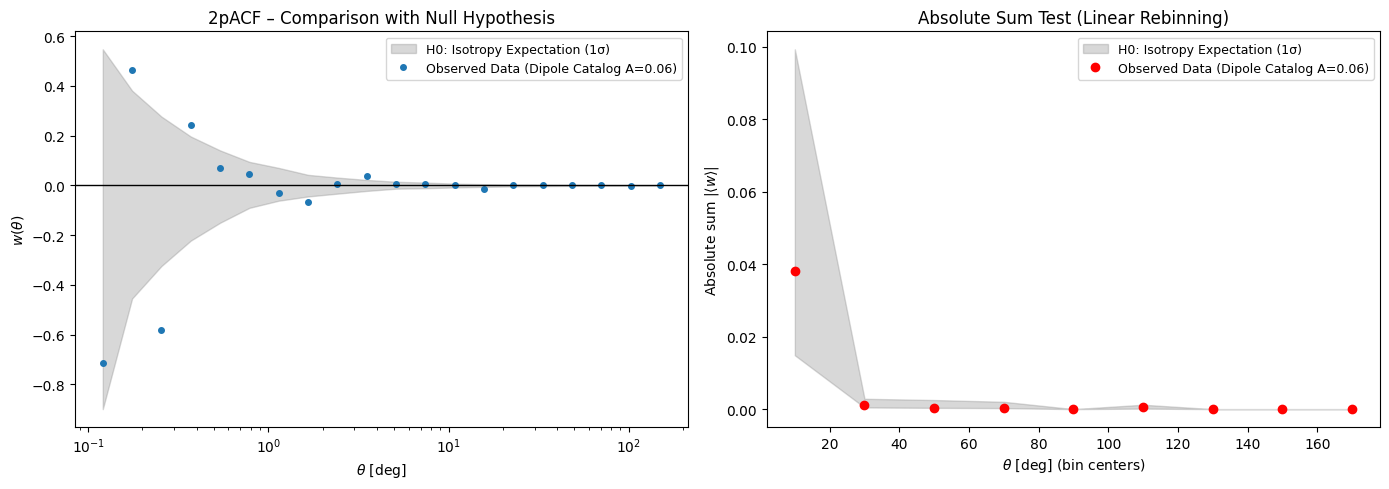

In [6]:
# ==============================================================
# Visualization
# ==============================================================

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: 2pACF compared to isotropy envelope ---
# Use 16th/84th percentiles (≈ 1σ) instead of mean ± std for a more robust
# envelope that handles non-Gaussian scatter in w(θ).
w_lo = np.percentile(w_bench, 16, axis=0)
w_hi = np.percentile(w_bench, 84, axis=0)

ax[0].fill_between(
    theta_bench, w_lo, w_hi,
    color="gray", alpha=0.3, label="H0: Isotropy Expectation (1σ)"
)
ax[0].plot(
    theta_sig, w_sig, "o", ms=4, color="tab:blue",
    label="Observed Data (Dipole Catalog A=0.06)"
)
ax[0].axhline(0, color="k", lw=1)
ax[0].set_xscale("log")
ax[0].set_title("2pACF – Comparison with Null Hypothesis")
ax[0].set_xlabel(r"$\theta$ [deg]")
ax[0].set_ylabel(r"$w(\theta)$")
ax[0].legend(fontsize=9)

# --- Plot 2: Absolute Sum Test with percentile envelope ---
abs_lo = np.percentile(abs_bench, 16, axis=0)
abs_hi = np.percentile(abs_bench, 84, axis=0)

ax[1].fill_between(
    BIN_CENTERS, abs_lo, abs_hi,
    color="gray", alpha=0.3, label="H0: Isotropy Expectation (1σ)"
)
ax[1].plot(
    BIN_CENTERS, abs_sig, "ro",
    label="Observed Data (Dipole Catalog A=0.06)"
)
ax[1].set_title("Absolute Sum Test (Linear Rebinning)")
ax[1].set_xlabel(r"$\theta$ [deg] (bin centers)")
ax[1].set_ylabel(r"Absolute sum $|\langle w \rangle|$")
ax[1].legend(fontsize=9)

plt.tight_layout()
plt.show()